In [ ]:
include("PermBasis.jl")
include("PlotSetup.jl")
include("MonteCarloMF.jl")
using PyPlot
using DifferentialEquations
using JLD2
using DiffEqCallbacks

legend_kwargs = (
    fontsize=12,
    framealpha=0.9,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=2.0,
    prop=Dict("family" => "serif", "size" => 12)
)

(fontsize = 12, framealpha = 0.9, borderpad = 0.3, labelspacing = 0.3, handlelength = 2.0, prop = Dict{String, Any}("family" => "serif", "size" => 12))

In [489]:
using JLD2

function generate_spont_sharpening_data(;
    outfile = "../plot_data/spont_sharpening_data.jld2",
    powers = [10, 23, 300],
    gs = range(0.0, 1.0, 300),
    r = 0.0,
    tmax = 1e15,
    reltol = 1e-8,
    abstol = 1e-10,
    cb = TerminateSteadyState(1e-1, 1e-1),
)
    curves = NamedTuple[]

    for pow in powers
        N = BigInt(10)^pow
        Nf = Float64(N)

        intens = Float64[]
        max_t = Float64[]
        for g in gs
            Γ = 1.0
            ξ = Nf * r
            γ = Nf * g / log(Nf)

            p = [Γ, ξ, Nf, γ]
            u0 = [-log(Nf), 0.5]


            t_end = 100.0 * log(Nf) / Nf
            u0 = [-log(Nf), 0.5]
            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, t_end), p)
            sol = solve(prob, AutoTsit5(Rosenbrock23()), reltol=reltol, abstol=abstol, saveat = range(0.0, t_end, 10000))
            
            max_ind = argmax(map(x -> x[1], sol.u))
            max_log_I = maximum(x -> x[1], sol.u)
            push!(intens, exp(max_log_I))
            push!(max_t, sol.t[max_ind])
        end

        push!(curves, (
            pow = pow,
            N = string(N),
            gs = collect(gs),
            intens = collect(intens),
            max_t = collect(max_t)
        ))
    end

    jldsave(outfile;
        powers = collect(powers),
        gs = collect(gs),
        r = r,
        curves = curves,
    )

    return (
        powers = collect(powers),
        gs = collect(gs),
        r = r,
        curves = curves,
    )
end

function generate_spont_collapse_data(;
    outfile = "../plot_data/spont_collapse_data.jld2",
    Ns = [1000, 10000, 50000],
    N_traj = 500,
    gs = range(0.0, 1.0, 300),
    r = 0.0,
    time_factor = 8.0,
)
    mf_itens = zeros(length(gs), length(Ns))
    mc_intens = zeros(length(gs), length(Ns))
    mf_t = zeros(length(gs), length(Ns))
    mc_t = zeros(length(gs), length(Ns))

    for (i, g) in enumerate(gs)
        for (j, N) in enumerate(Ns)
            params = Dict(
                "global_decay" => 1.0,
                "global_pump" => 0.0,
                "local_pump" => 0.0,
                "local_dephasing" => r * N,
                "local_decay" => g * N / log(N),
            )

            imc, imf, tmc, tmf = mc_vs_mf_data(N, params, N_traj; time_factor=time_factor)

            mf_itens[i, j] = imf
            mc_intens[i, j] = imc
            mf_t[i, j] = tmf
            mc_t[i, j] = tmc
        end
    end

    jldsave(outfile;
        Ns = Ns,
        N_traj = N_traj,
        gs = collect(gs),
        r = r,
        time_factor = time_factor,
        mf_itens = mf_itens,
        mc_intens = mc_intens,
        mf_t = mf_t,
        mc_t = mc_t,
    )

    return (
        Ns = Ns,
        N_traj = N_traj,
        gs = collect(gs),
        r = r,
        time_factor = time_factor,
        mf_itens = mf_itens,
        mc_intens = mc_intens,
        mf_t = mf_t,
        mc_t = mc_t,
    )
end

function plot_spont_scaling_single!(ax, data_sharp, data_coll;
    colors_mc = ["red", "blue", "orange"],
    colors_sharp = ["blue", "green", "violet"],
    mf_linestyle = "solid",
    sharp_linestyle = "solid",
)
    gs = data_coll["gs"]
    Ns = data_coll["Ns"]
    mc = data_coll["mc_intens"]
    mf = data_coll["mf_itens"]

    for j in (1:length(Ns))[[1,3]]
        ax.scatter(
            gs[1:5:end],
            mc[:, j][1:5:end] ./ mc[1, j],
            facecolor = colors_mc[j],
            edgecolor = "k",
            s = 18,
            linewidths=0.45,
            label = "MC " * sci_label(Ns[j])
        )

        ax.plot(
            gs,
            mf[:, j] ./ mf[1, j],
            color = colors_mc[j],
            linestyle = mf_linestyle,
            linewidth = 1.1,
            alpha = 1.0,
            label = "MF " * sci_label(Ns[j])
        )
    end

    for (i, curve) in enumerate(data_sharp["curves"][[1,2]])
        @show curve.pow
        ax.plot(
            curve.gs,
            curve.intens ./ curve.intens[1],
            color = colors_sharp[i],
            linestyle = sharp_linestyle,
            linewidth = 1.8,
            alpha = 0.85,
            label = "\$N=10^{$(curve.pow)}\$ MF"
        )
    end

    ax.set_yscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(L"\bar g_\gamma")
    ax.set_ylabel(L"I_\star(\bar g_\gamma)/I_\star(0)")
    ax.legend(; legend_kwargs...)
    ax.set_ylim(bottom = 1e-7, top = 10)

    return ax
end

function generate_spont_phase_diagram_data(;
    outfile = nothing,
    gs = range(0.0, 0.38, 200),
    rs = range(0.0, 1.2, 200),
    pow = 200,
    tmax = 1e15,
    reltol = 1e-8,
    abstol = 1e-10,
    cb = TerminateSteadyState(1e-1, 1e-1),
)
    N = BigInt(10)^pow
    Nf = Float64(N)

    data = zeros(length(rs), length(gs))

    for (i, r) in enumerate(rs)
        for (j, g) in enumerate(gs)
            Γ = 1.0
            ξ = Nf * r
            γ = Nf * g / log(Nf)

            p = [Γ, ξ, Nf, γ]
            u0 = [-log(Nf), 0.5]

            t_end = 100.0 * log(Nf) / Nf
            u0 = [-log(Nf), 0.5]
            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, t_end), p)
            sol = solve(prob, AutoTsit5(Rosenbrock23()), reltol=reltol, abstol=abstol, saveat = range(0.0, t_end, 30000))

            data[i, j] = exp(maximum(x -> x[1], sol.u))
        end
    end

    result = (
        gs = collect(gs),
        rs = collect(rs),
        data = data,
        pow = pow,
        N = string(N),
    )

    if outfile !== nothing
        jldsave(outfile; result...)
    end

    return result
end

function analytic_spont_boundary(rs)
    return (1 .- rs) .- (1 .+ rs) .* log.(2 ./ (1 .+ rs))
end

function plot_spont_phase_diagram!(
    ax,
    d;
    show_contour = true,
    contour_tol = 1e-2,
    show_analytic_boundary = true,
    rescale_intensity = 4.0,
    cmap = "viridis",
    add_colorbar = true,
    colorbar_label = L"I/N^2",
    boundary_color = "red",
    analytic_color = "white",
    analytic_linestyle = "--",
)
    gs = d["gs"]
    rs = d["rs"]
    data = d["data"]

    im = ax.imshow(
        rescale_intensity .* data,
        extent = [first(gs), last(gs), first(rs), last(rs)],
        origin = "lower",
        aspect = "auto",
        cmap = cmap
    )

    if show_contour
        mask = Float64.(data .<= contour_tol)
        ax.contour(
            gs, rs, mask,
            levels = [0.5],
            colors = boundary_color,
            linewidths = 2,
            zorder = 10
        )
    end

    if show_analytic_boundary
        rb = collect(rs)
        gb = analytic_spont_boundary(rb)
        valid = (gb .>= minimum(gs)) .& (gb .<= maximum(gs))
        ax.plot(
            gb[valid], rb[valid],
            color = analytic_color,
            linestyle = analytic_linestyle,
            linewidth = 2.0,
            zorder = 11
        )
    end

    ax.set_xlabel(L"\bar g_\gamma")
    ax.set_ylabel(L"g_\xi")

    if add_colorbar
        cbar = ax.figure.colorbar(im, ax=ax, pad=0.02)
        cbar.ax.set_title(colorbar_label)
    end

    return im
end

using JLD2

function generate_spont_meanfield_g_gamma_data(;
    outfile = "../plot_data/spont_meanfield_g_gamma_data.jld2",
    powers = [5, 10, 15],
    gs = range(0.0, 0.2, 300),
    r = 0.0,
    tmax = 1e15,
    reltol = 1e-8,
    abstol = 1e-10,
    cb = TerminateSteadyState(1e-1, 1e-1),
)
    curves = NamedTuple[]

    for pow in powers
        N = BigInt(10)^pow
        Nf = Float64(N)

        intens = Float64[]
        for g in gs
            Γ = 1.0
            ξ = Nf * r
            γ = Nf * g

            p = [Γ, ξ, Nf, γ]
            u0 = [-log(Nf), 0.5]

            t_end = 100.0 * log(Nf) / Nf
            u0 = [-log(Nf), 0.5]
            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, t_end), p)
            sol = solve(prob, AutoTsit5(Rosenbrock23()), reltol=reltol, abstol=abstol, saveat = range(0.0, t_end, 30000))

            max_log_I = maximum(x -> x[1], sol.u)
            push!(intens, exp(max_log_I))
        end

        push!(curves, (
            pow = pow,
            N = string(N),
            gs = collect(gs),
            intens = collect(intens),
        ))
    end

    jldsave(outfile;
        powers = collect(powers),
        gs = collect(gs),
        r = r,
        curves = curves,
    )

    return (
        powers = collect(powers),
        gs = collect(gs),
        r = r,
        curves = curves,
    )
end

function plot_spont_meanfield_g_gamma!(ax, data;
    colors = ["red", "blue", "orange"],
    linestyle = "solid",
)
    for (i, curve) in enumerate(data["curves"])
        ax.plot(
            curve.gs,
            curve.intens ./ curve.intens[1],
            color = colors[i],
            linestyle = linestyle,
            linewidth = 1.8,
            alpha = 0.9,
            label = "\$N=10^{$(curve.pow)}\$"
        )
    end

    ax.set_yscale("log")
    ax.set_xlabel(L"g_\gamma")
    ax.set_ylabel(L"I_\star(g_\gamma)/I_\star(0)")
    ax.legend(; legend_kwargs...)

    return ax
end


function plot_spont_peak_times!(ax, data_coll, data_mf;
    cs = ["red", "stub", "blue", "orange", "green"],
    xlabel = L"\bar g_{\gamma}",
    ylabel = L"N t_{\star} / \log N",
    ms = 2,
    lw = 1.5,
    mc_label_prefix = "MC",
    mf_label_prefix = "MF",
    legend_kwargs = (
        fontsize = 12,
        framealpha = 0.9,
        borderpad = 0.3,
        labelspacing = 0.3,
        handlelength = 2.0,
    ),
)
    # --- MC ---
    ncurves_mc = size(data_coll["mc_t"], 2)
    for j = 1:ncurves_mc
        if j==2 continue end
        N = data_coll["Ns"][j]
        ax.scatter(
            data_coll["gs"],
            data_coll["mc_t"][:, j] / log(N) * N;
            color = cs[j],
            s = ms,
        )
    end

    # --- MF ---
    ncurves_mf = length(data_mf["curves"])
    for j = 1:ncurves_mf
        if j==2 continue end
        N = parse(Float64, data_mf["curves"][j].N)
        ax.plot(
            data_mf["curves"][j].gs,
            data_mf["curves"][j].max_t / log(N) * N;
            color = cs[j],
            linestyle = "solid",
            linewidth = lw,
        )
    end

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # --- method legend (proxies) ---
    mc_proxy = ax.scatter([], []; color = "black", s = 30)
    mf_proxy, = ax.plot([], []; color = "black", linestyle = "solid", linewidth = lw)

    leg1 = ax.legend(
        [mc_proxy, mf_proxy],
        [mc_label_prefix, mf_label_prefix];
        loc = "upper right",
        legend_kwargs...
    )

    # --- N legend (MF-style proxies only) ---
    n_proxies = Any[]
    n_labels = Any[]

    for j = 1:ncurves_mf
        if j==2 continue end
        N = parse(Float64, data_mf["curves"][j].N)

        proxy, = ax.plot(
            [],
            [];
            color = cs[j],
            linestyle = "solid",
            linewidth = lw,
        )

        push!(n_proxies, proxy)
        push!(n_labels, sci_label(N))
    end

    leg2 = ax.legend(
        n_proxies,
        n_labels;
        loc = "lower left",
        legend_kwargs...
    )

    ax.add_artist(leg1)
    ax.set_yscale(:log)

    mticker = PyPlot.matplotlib["ticker"]
    ax.set_yticks([0.6, 1.0, 2.0])
    ax.get_yaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_locator(mticker.NullLocator())

    return ax
end

plot_spont_peak_times! (generic function with 1 method)

curve.pow = 10
curve.pow = 

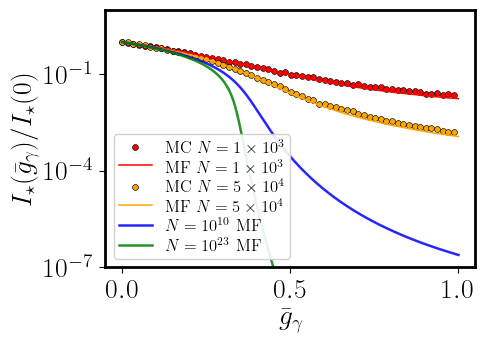

23


PyObject <Axes: xlabel='$\\bar g_\\gamma$', ylabel='$I_\\star(\\bar g_\\gamma)/I_\\star(0)$'>

In [467]:
data_sharp = load("../plot_data/spont_sharpening_data.jld2")
data_coll = load("../plot_data/spont_collapse_data.jld2")
width, height = latex_plot_setup(scale = 2.0, ratio = 0.7)
fig, ax = subplots(figsize = (width, height))
plot_spont_scaling_single!(ax, data_sharp, data_coll)

In [ ]:
data_sharp = generate_spont_sharpening_data()
data_coll = generate_spont_collapse_data()

data_sharp = load("../plot_data/spont_sharpening_data.jld2")
data_coll = load("../plot_data/spont_collapse_data.jld2")

Dict{String, Any} with 9 entries:
  "mf_t"        => [0.00693686 0.000923073 0.00021505; 0.00696028 0.00092621 0.…
  "mc_t"        => [0.00719126 0.000951459 0.000221811; 0.00724657 0.000951459 …
  "N_traj"      => 500
  "r"           => 0.0
  "gs"          => [0.0, 0.00334448, 0.00668896, 0.0100334, 0.0133779, 0.016722…
  "time_factor" => 8.0
  "mf_itens"    => [0.250895 0.25007 0.24974; 0.248063 0.247126 0.246862; … ; 0…
  "Ns"          => [1000, 10000, 50000]
  "mc_intens"   => [1.93009e5 1.9812e7 4.74654e8; 1.92863e5 1.87321e7 4.85338e8…

In [246]:
d = generate_spont_phase_diagram_data(
    outfile = "../plot_data/spont_phase_diagram.jld2",
    gs = range(0.0, 0.38, 200),
    rs = range(0.0, 1.2, 200),
    pow = 200
)

(gs = [0.0, 0.0019095477386934674, 0.003819095477386935, 0.005728643216080402, 0.00763819095477387, 0.009547738693467337, 0.011457286432160804, 0.013366834170854271, 0.01527638190954774, 0.017185929648241206  …  0.3628140703517588, 0.3647236180904523, 0.36663316582914574, 0.3685427135678392, 0.37045226130653264, 0.37236180904522614, 0.3742713567839196, 0.37618090452261305, 0.37809045226130655, 0.38], rs = [0.0, 0.006030150753768844, 0.012060301507537688, 0.018090452261306532, 0.024120603015075376, 0.03015075376884422, 0.036180904522613064, 0.04221105527638191, 0.04824120603015075, 0.054271356783919596  …  1.1457286432160805, 1.1517587939698493, 1.157788944723618, 1.163819095477387, 1.1698492462311558, 1.1758793969849246, 1.1819095477386934, 1.1879396984924624, 1.1939698492462312, 1.2], data = [0.2499852849237404 0.22210569688870388 … 1.0381361001646376e-38 1.586895303769309e-39; 0.24144427699206894 0.22540827571629277 … 6.567842024652663e-41 1.0301306259027272e-41; … ; 9.99999999999978

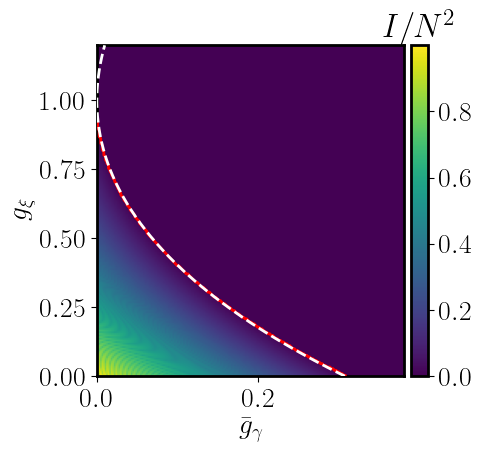

PyObject <matplotlib.image.AxesImage object at 0x402e89590>

In [248]:
d = load("../plot_data/spont_phase_diagram.jld2")

width, height = latex_plot_setup(scale = 2.0, ratio = 0.9)
fig, ax = subplots(figsize = (width, height))

plot_spont_phase_diagram!(
    ax, d;
    show_contour = true,
    show_analytic_boundary = true,
    contour_tol=1e-3,
    rescale_intensity = 4.0
)

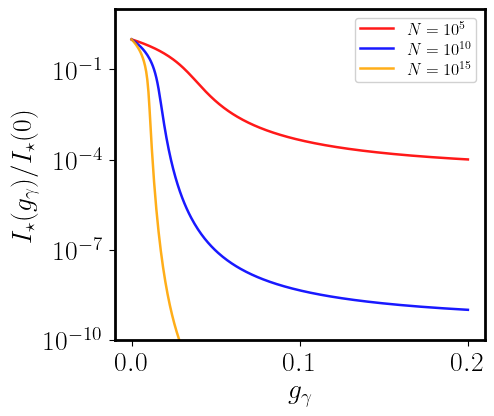

(1.0e-10, 10)

In [ ]:
generate_spont_meanfield_g_gamma_data()
data = load( "../plot_data/spont_meanfield_g_gamma_data.jld2")
width, height = latex_plot_setup(scale = 2.0, ratio = 0.9)
fig, ax = subplots(figsize = (width, height))
plot_spont_meanfield_g_gamma!(ax, data)
ylim(bottom = 1e-10, top = 10)

In [399]:
generate_spont_sharpening_data(; outfile = "../plot_data/times_spont_meanfield.jld2", powers = [3, 4, 4.69897000434, 10, 23])


(powers = [3.0, 4.0, 4.69897000434, 10.0, 23.0], gs = [0.0, 0.0033444816053511705, 0.006688963210702341, 0.010033444816053512, 0.013377926421404682, 0.016722408026755852, 0.020066889632107024, 0.023411371237458192, 0.026755852842809364, 0.030100334448160536  …  0.9698996655518395, 0.9732441471571907, 0.9765886287625418, 0.979933110367893, 0.9832775919732442, 0.9866220735785953, 0.9899665551839465, 0.9933110367892977, 0.9966555183946488, 1.0], r = 0.0, curves = NamedTuple[(pow = 3.0, N = "1000.0", gs = [0.0, 0.0033444816053511705, 0.006688963210702341, 0.010033444816053512, 0.013377926421404682, 0.016722408026755852, 0.020066889632107024, 0.023411371237458192, 0.026755852842809364, 0.030100334448160536  …  0.9698996655518395, 0.9732441471571907, 0.9765886287625418, 0.979933110367893, 0.9832775919732442, 0.9866220735785953, 0.9899665551839465, 0.9933110367892977, 0.9966555183946488, 1.0], intens = [0.250990200765134, 0.2482362930790977, 0.24548257786202324, 0.24273004456497735, 0.2399796

curve.pow = 10
curve.pow = 

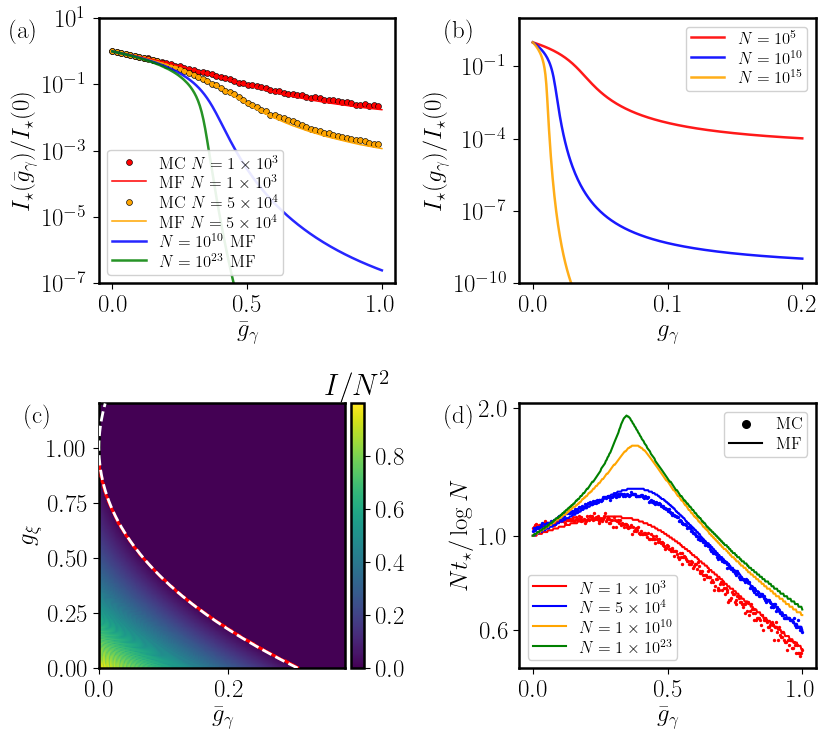

23


In [488]:
fig, axes = subplots(ncols = 2, nrows = 2, figsize = 2.0 .* latex_plot_setup(ratio=0.9, scale=1.8))


data_sharp = load("../plot_data/spont_sharpening_data.jld2")
data_coll = load("../plot_data/spont_collapse_data.jld2")
plot_spont_scaling_single!(axes[1,1], data_sharp, data_coll)

data = load( "../plot_data/spont_meanfield_g_gamma_data.jld2")
plot_spont_meanfield_g_gamma!(axes[1,2], data)
axes[1,2].set_ylim(bottom = 1e-10, top = 10)

d = load("../plot_data/spont_phase_diagram.jld2")
plot_spont_phase_diagram!(
    axes[2,1], d;
    show_contour = true,
    show_analytic_boundary = true,
    contour_tol=1e-3,
    rescale_intensity = 4.0
)

data_mc = load("../plot_data/spont_collapse_data.jld2")
data_mf = load("../plot_data/times_spont_meanfield.jld2")
plot_spont_peak_times!(axes[2,2], data_mc, data_mf)

tight_layout()

axes[1,1].text(-0.3, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.25, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[2,1].text(-0.3, 1.0, "(c)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.25, 1.0, "(d)", transform=axes[2,2].transAxes, va="top")
savefig("../data/fig5.pdf", bbox_inches = "tight")
